In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [33]:
actual_response = requests.get("https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream?settlementDateFrom=2023-01-01&settlementDateTo=2026-03-01&settlementPeriod=3&settlementPeriod=4&fuelType=WIND")
actual_response = actual_response.json()

In [34]:
actual_df = pd.DataFrame(actual_response)

In [35]:
actual_df = actual_df.sort_values('startTime')

In [36]:
actual_df.head()

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
2311,FUELHH,2023-01-01T01:30:00Z,2023-01-01T01:00:00Z,2023-01-01,3,WIND,12264
2310,FUELHH,2023-01-01T02:00:00Z,2023-01-01T01:30:00Z,2023-01-01,4,WIND,12214
2309,FUELHH,2023-01-02T01:30:00Z,2023-01-02T01:00:00Z,2023-01-02,3,WIND,4575
2308,FUELHH,2023-01-02T02:00:00Z,2023-01-02T01:30:00Z,2023-01-02,4,WIND,4858
2307,FUELHH,2023-01-03T01:30:00Z,2023-01-03T01:00:00Z,2023-01-03,3,WIND,7224


In [37]:
def preprocess_actual(df):
  df = df.copy()
  df['startTime'] = pd.to_datetime(df['startTime'])
  return df[['startTime', 'generation']]

def preprocess_forecast(df):
  df = df.copy()
  df['startTime'] = pd.to_datetime(df['startTime'])
  df['publishTime'] = pd.to_datetime(df['publishTime'])
  df['horizon'] = (df['startTime'] - df['publishTime']).dt.total_seconds()/3600
  return df[['startTime', 'publishTime', 'horizon', 'generation']]

In [38]:
actual_df = preprocess_actual(actual_df).reset_index()

In [39]:
actual_df.head()

,index,startTime,generation
0,2311,2023-01-01 01:00:00+00:00,12264
1,2310,2023-01-01 01:30:00+00:00,12214
2,2309,2023-01-02 01:00:00+00:00,4575
3,2308,2023-01-02 01:30:00+00:00,4858
4,2307,2023-01-03 01:00:00+00:00,7224


In [40]:
horizon_pts = [4]
horizon_pts = [float(4) for h in horizon_pts]

In [41]:
# General metrics to determine model performance
def calculate_metrics(data):
  min = data.min()
  max = data.max()
  mean = data.mean()
  med = data.median()
  std = data.std()
  p10 = data.quantile(0.10)
  p20 = data.quantile(0.20)
  p50 = data.quantile(0.50)
  p90 = data.quantile(0.90)

  print('Min:', min)
  print('Max:', max)
  print('Mean:', mean)
  print('Median', med)
  print('Std:', std)
  print('percetile 10:', p10)
  print('percetile 20:', p20)
  print('percetile 50:', p50)
  print('percetile 90:', p90)

In [42]:
# Histogram of Power vs time
def hist_plot(df):
  plt.figure(figsize=(10, 5))
  plt.hist(df["generation"], bins=50)
  plt.title("Frecuency vs Power")
  plt.xlabel("Power")
  plt.ylabel("Frequency")
  plt.show()

Min: 223
Max: 17496
Mean: 7677.66392733564
Median 7108.5
Std: 4226.8124025149655
percetile 10: 2338.2
percetile 20: 3531.0
percetile 50: 7108.5
percetile 90: 13833.2


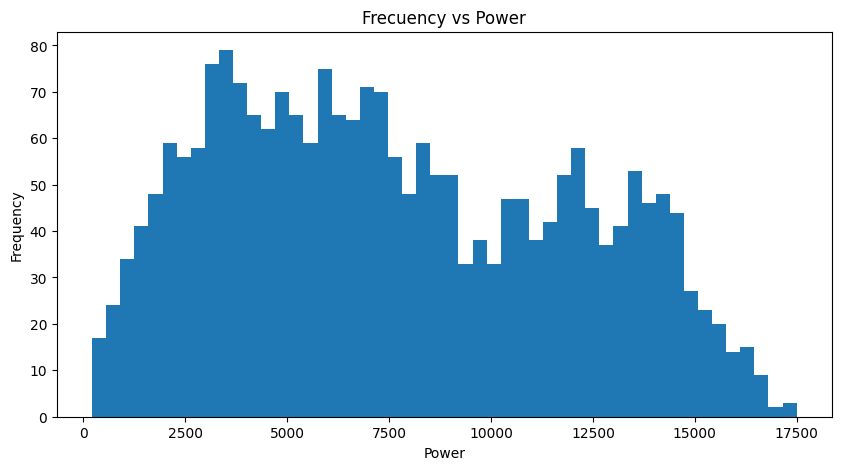

In [43]:
calculate_metrics(actual_df["generation"])
hist_plot(actual_df)

In [44]:
# p10 = 2847.8
# 90% percent of the time we will get wind power >= p10
# Let's assume power usage of 1 home = 1kW power / hour - From Google
# Assuming needs to survive 1 season = 3 months

In [45]:
def home_survival_count(avg_power):
  # 3 months in hour
  hours = 3 * 30 * 24

  # Avg Wind power generation in time
  # avg_power is p10 and taking in consideration half-hourly generation
  energy_total = avg_power * 0.5

  # Energy need for 1 home for 3 months
  energy_need = 1 * hours / 1000 # MWh

  homes = energy_total // energy_need
  print(f"No. of homes to survive for 3 months: {homes}")
home_survival_count(2847.8)

No. of homes to survive for 3 months: 659.0


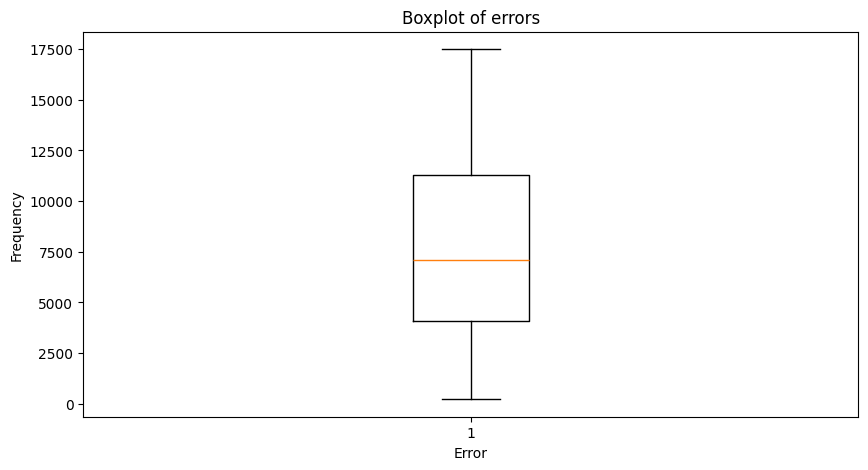

In [46]:
# Boxplot for outlier analysis
plt.figure(figsize=(10, 5))
plt.boxplot(actual_df["generation"])
plt.title("Boxplot of errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [47]:
# Boxplot found no outliers

In [48]:
season_df = pd.DataFrame({
    "season" : ["winter", "spring", "summer", "autumn"],
    "from" : ["21-12", "20-03", "21-06", "23-09"],
    "to" : ["19-03", "20-06", "22-09", "20-12"]
})

In [49]:
season_df

,season,from,to
0,winter,21-12,19-03
1,spring,20-03,20-06
2,summer,21-06,22-09
3,autumn,23-09,20-12


In [50]:
season_df["from"] = pd.to_datetime(season_df["from"], format="%d-%m").dt.strftime("%m-%d")
season_df["to"] = pd.to_datetime(season_df["to"], format="%d-%m").dt.strftime("%m-%d")

In [51]:
season_df

,season,from,to
0,winter,12-21,03-19
1,spring,03-20,06-20
2,summer,06-21,09-22
3,autumn,09-23,12-20


In [52]:
ex_df = pd.DataFrame({
    "year" : [2024, 2024, 2025, 2025],
    "val" : [4, 2 , 3, 1]
})

def func(val):
  if 1 <= val and val <= 2:
    return 0
  elif 3 <= val and val <= 4:
    return 1
  else:
    return None

ex_df["new_val"] = ex_df["val"].apply(func)
ex_df

,year,val,new_val
0,2024,4,1
1,2024,2,0
2,2025,3,1
3,2025,1,0


In [53]:
def get_season(startTime):
  startTime = pd.to_datetime(startTime).strftime("%m-%d")
  for i in range(len(season_df)):
    start = season_df.iloc[i]["from"]
    end   = season_df.iloc[i]["to"]
    if start <= startTime <= end:
      return season_df.iloc[i]["season"]
  return "winter"

In [54]:
actual_df["season"] = actual_df["startTime"].apply(get_season)

In [55]:
actual_df[200:205]

,index,startTime,generation,season
200,2111,2023-04-11 00:00:00+00:00,12584,spring
201,2110,2023-04-11 00:30:00+00:00,13058,spring
202,2109,2023-04-12 00:00:00+00:00,12613,spring
203,2108,2023-04-12 00:30:00+00:00,12127,spring
204,2107,2023-04-13 00:00:00+00:00,10708,spring


In [56]:
seasons = season_df["season"].unique()
def plot_seasonsalwise_error():
  df = actual_df.copy()

  years = df["startTime"].dt.year.unique()

  for year in years:
    temp_df = df[df["startTime"].dt.year == year]
    print(f"Len {year}:", len(temp_df))

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
    axes = axes.flatten()

    for i, season in enumerate(seasons):
      s_df = temp_df[temp_df["season"] == season]
      mean = round(s_df["generation"].mean(), 2)
      p10 = s_df["generation"].quantile(0.10)
      print(f"{season} {year}:", "Len", len(s_df), "|", "Mean:", mean)
      home_survival_count(p10)
      axes[i].hist(s_df["generation"], bins=50)
      axes[i].set_title(season + " " + str(year))
      axes[i].tick_params(axis='x', labelbottom=True)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


Len 2023: 730
winter 2023: Len 178 | Mean: 9322.96
No. of homes to survive for 3 months: 861.0
spring 2023: Len 186 | Mean: 5478.84
No. of homes to survive for 3 months: 423.0
summer 2023: Len 188 | Mean: 5354.55
No. of homes to survive for 3 months: 313.0
autumn 2023: Len 178 | Mean: 8498.19
No. of homes to survive for 3 months: 709.0


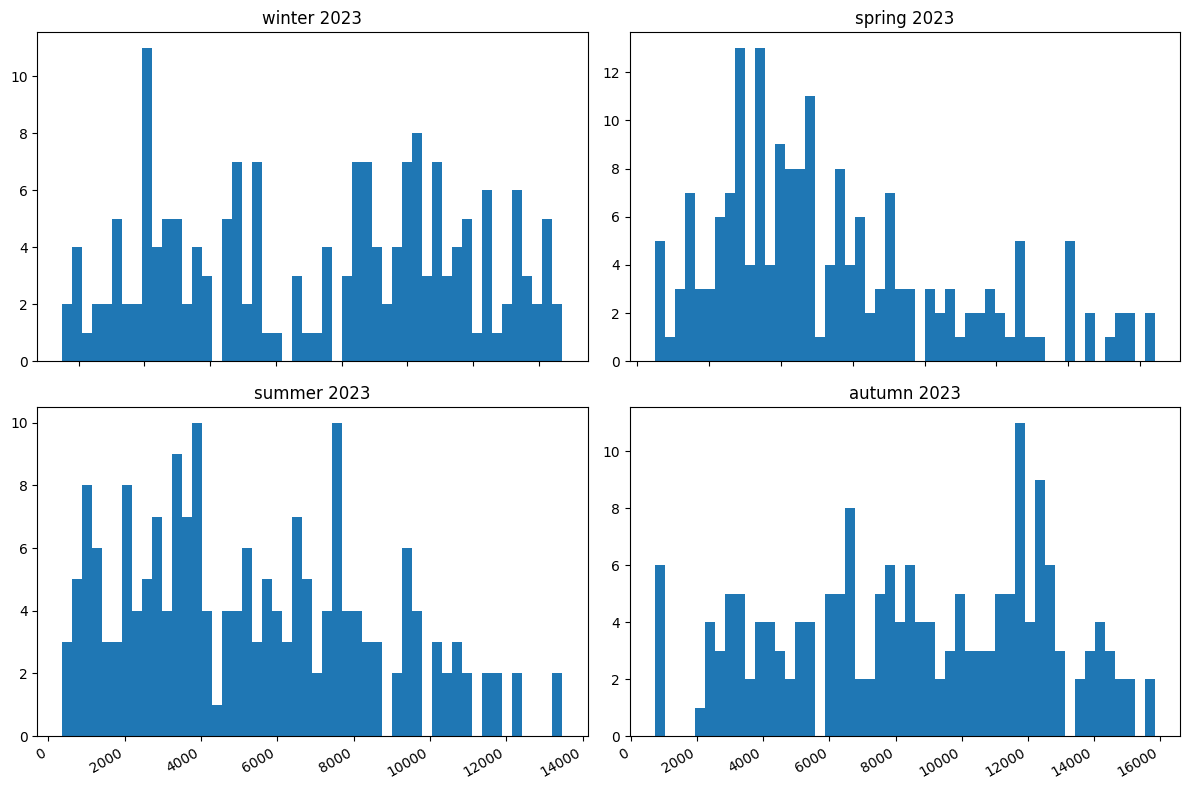

Len 2024: 732
winter 2024: Len 180 | Mean: 9182.15
No. of homes to survive for 3 months: 784.0
spring 2024: Len 186 | Mean: 6601.24
No. of homes to survive for 3 months: 369.0
summer 2024: Len 188 | Mean: 5631.26
No. of homes to survive for 3 months: 457.0
autumn 2024: Len 178 | Mean: 8271.2
No. of homes to survive for 3 months: 562.0


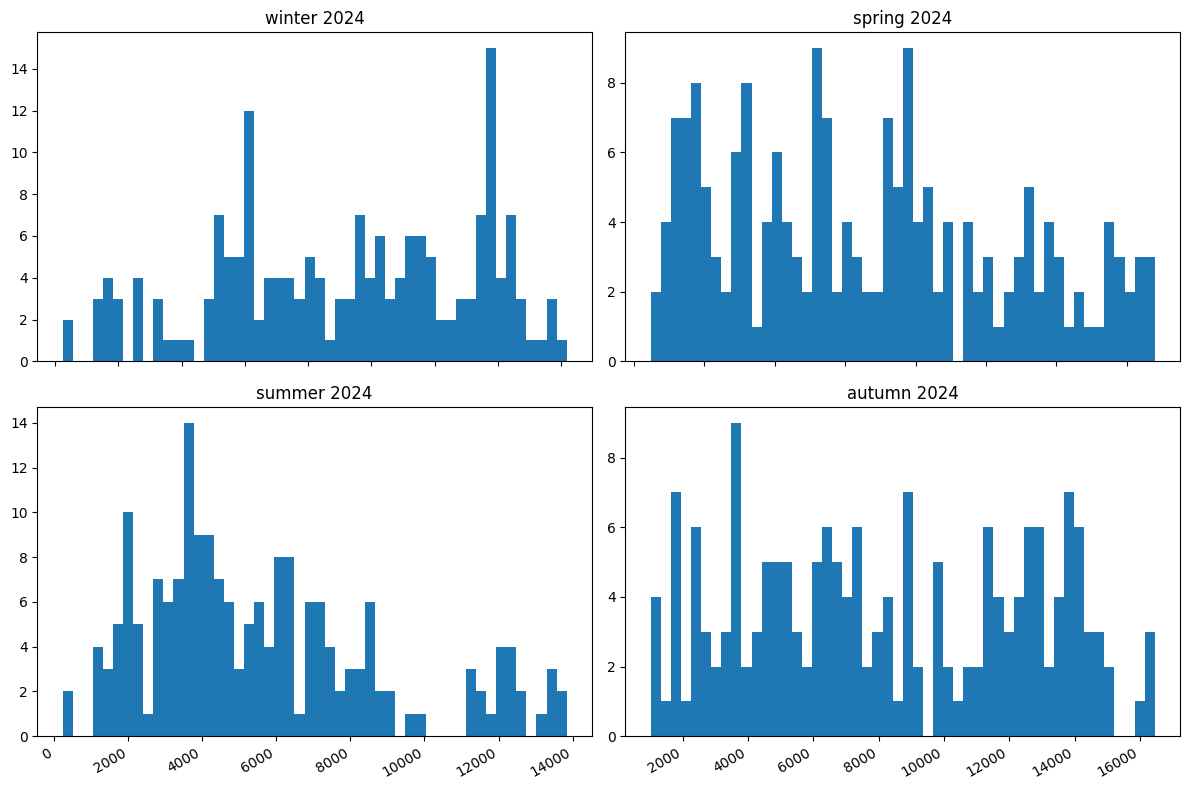

Len 2025: 730
winter 2025: Len 178 | Mean: 8355.72
No. of homes to survive for 3 months: 756.0
spring 2025: Len 186 | Mean: 6471.23
No. of homes to survive for 3 months: 516.0
summer 2025: Len 188 | Mean: 6869.74
No. of homes to survive for 3 months: 503.0
autumn 2025: Len 178 | Mean: 10020.33
No. of homes to survive for 3 months: 840.0


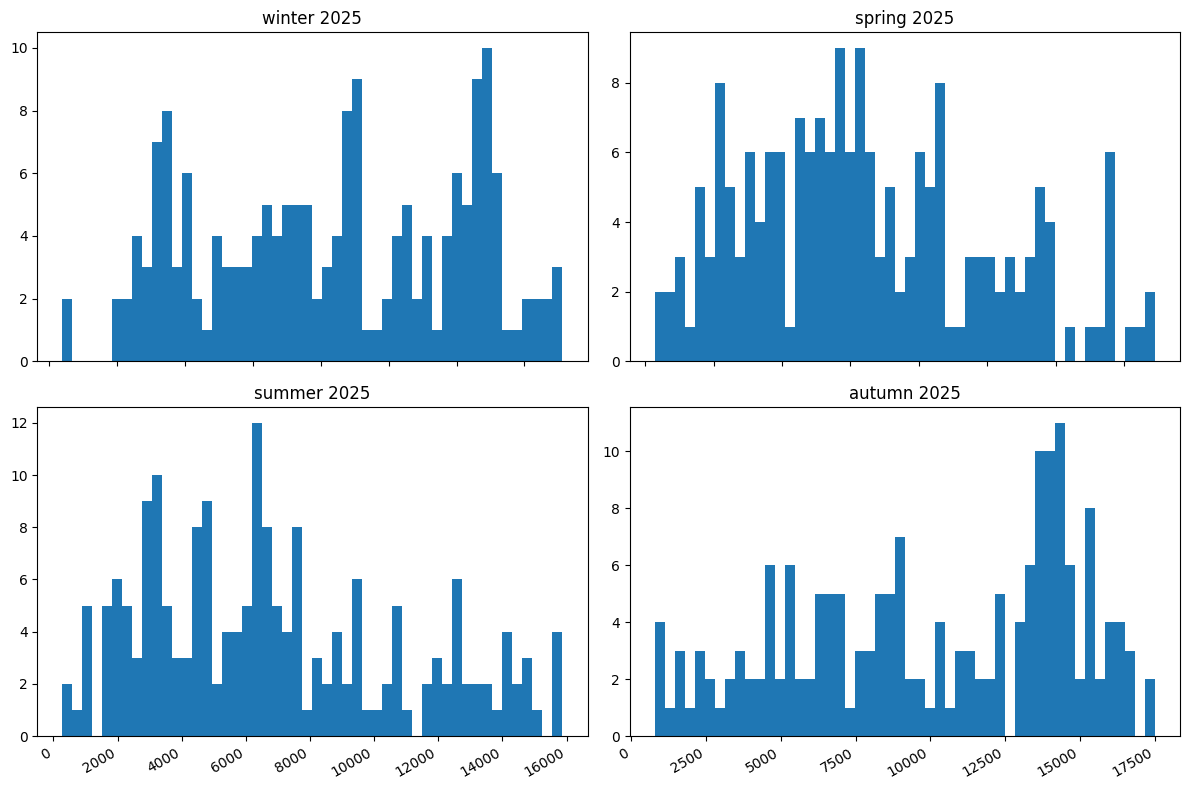

Len 2026: 120
winter 2026: Len 120 | Mean: 11460.08
No. of homes to survive for 3 months: 1562.0
spring 2026: Len 0 | Mean: nan
No. of homes to survive for 3 months: nan
summer 2026: Len 0 | Mean: nan
No. of homes to survive for 3 months: nan
autumn 2026: Len 0 | Mean: nan
No. of homes to survive for 3 months: nan


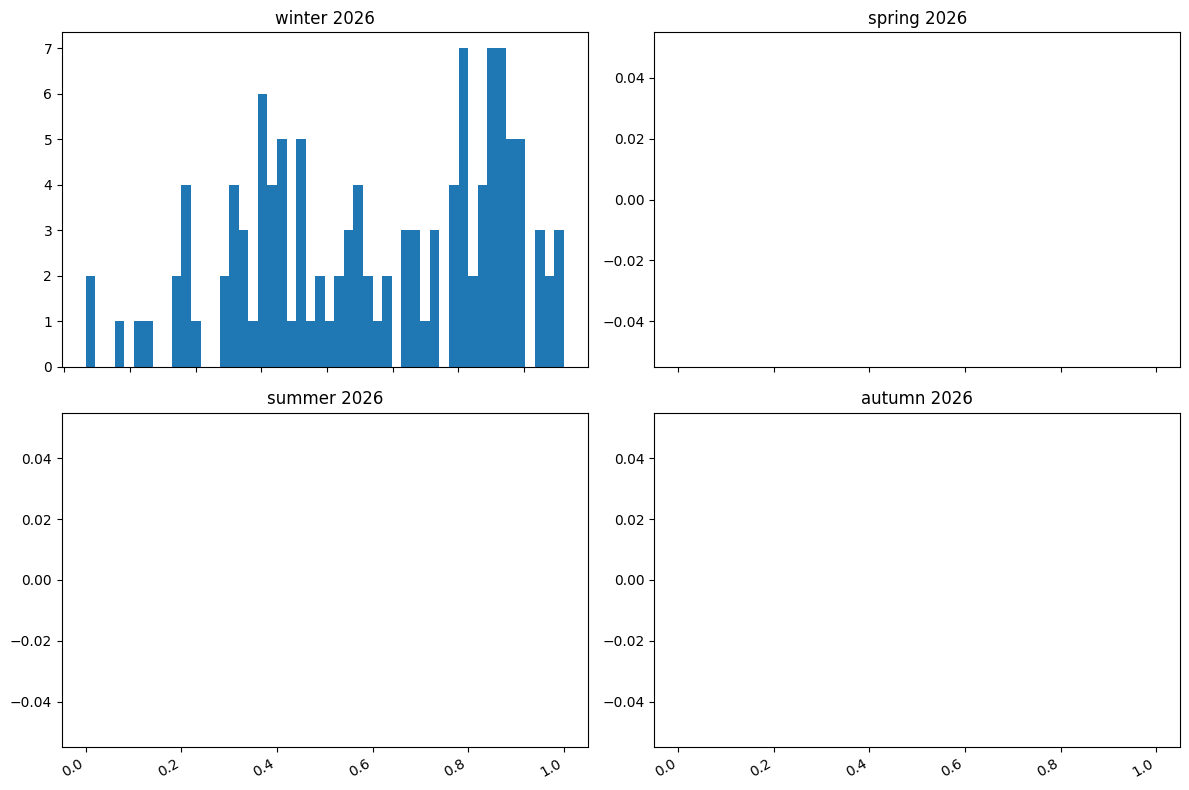

In [57]:
plot_seasonsalwise_error()

In [58]:
# Wind power is higher in winter and spring which is consistent with Google search result

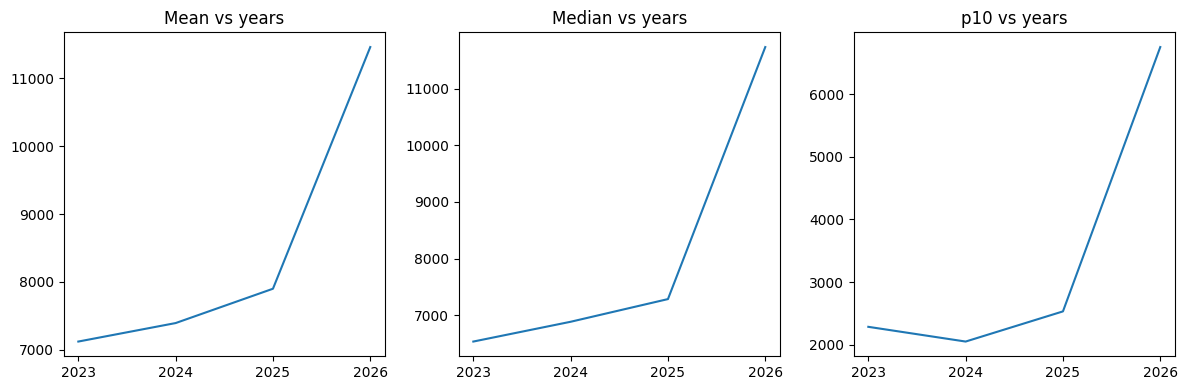

In [59]:
# Year wise mean, median and p10
years = actual_df["startTime"].dt.year.unique()

means = []
medians = []
p10s = []

for year in years:
  df = actual_df[actual_df["startTime"].dt.year == year].copy()
  mean = round(df["generation"].mean(), 2)
  median = round(df["generation"].median(), 2)
  p10 = round(df["generation"].quantile(0.10),2)

  means.append(mean)
  medians.append(median)
  p10s.append(p10)

_, axes = plt.subplots(1,3,figsize=(12,4))
axes = axes.flatten()

axes[0].plot(years, means)
axes[0].set_title("Mean vs years")
axes[0].set_xticks(years)

axes[1].plot(years, medians)
axes[1].set_title("Median vs years")
axes[1].set_xticks(years)

axes[2].plot(years, p10s)
axes[2].set_title("p10 vs years")
axes[2].set_xticks(years)

plt.tight_layout()
plt.show()

In [60]:
# Showing increasing trend
# Means either more wind turbines or more winds